# Phase Transitions

## Phase Behavior

Up to this point we have been mainly concerned with calculating the VLE envelope from a volumetric equation of state. However, what is not probably obvious at this point is why this is necessary/useful. 

We have pointed out in class that we have three problem solving strategies:

1. Ideal Gas
2. Real Gas Properties
3. Cubic Equations of State

We now have all the tools we need to solve chemical engineering problems involving phase change using strategies (2) and (3), noting that phase change can never be computed using strategy (1).

> The ideal gas law can still be used to approximate the properties of the vapor phase at low pressures during the vapor-liquid transition!

The accuracy of (3) will depend on the quality of the E.O.S.. Let's see how accurate the Peng Robinson Equation of State is at predicted the VLE behavior of a few simple gases.

### Steam - $P-\underline{V}$ Diagram

The illustration below uses Phasepy, a python package, to calculate the VLE envelope using the Peng Robinson Equation of state. Comparing it with the NIST property database for steam, we see excellent agreement between the predicted values from the PR EOS and the real properties, indicating that the computation is highly accurate. 

C:\Users\richa\AppData\Roaming\Python\Python312\site-packages\phasepy\cubic\psatpure.py:28: UserWarning: Temperature is greater than critical temperature, returning critical point
  warn('Temperature is greater than critical temperature, returning critical point')


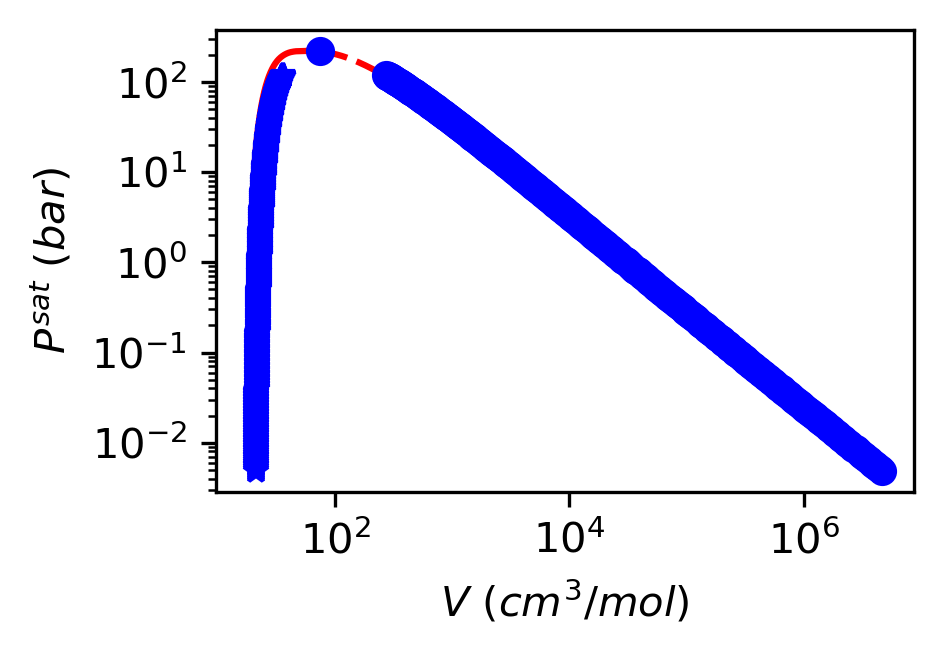

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from phasepy import component, mixture, preos
import pandas as pd
import os

## import real steam properties
directory = 'data'
filename = 'saturated_steam_properties.txt'
steam_properties = pd.read_csv(os.path.join(directory, filename), delimiter = '\t')

## instantiate a model class for the PREOS using phasepy 
water = component(name='water', Tc=647.1, Pc=220.64, w=0.344)
eos = preos(water)

V_v = []
V_l = []
Psat = []
Tsat = []
T_ = np.arange(min(steam_properties['Temperature (K)']), max(steam_properties['Temperature (K)']))
for T in list(steam_properties['Temperature (K)']):
    try:
        ps, vl, vv = eos.psat(T=T)
        V_v.append(vv)
        V_l.append(vl)
        Psat.append(ps)
        Tsat.append(T)
    except:
        pass#print('psat not found at T=%f'%T)
plt.figure(dpi=300, figsize=(3,2))
plt.plot(steam_properties['Volume (l, l/mol)']*10**3, 
         steam_properties['Pressure (MPa)']*10, '-r')
plt.plot(steam_properties['Volume (v, l/mol)']*10**3, 
         steam_properties['Pressure (MPa)']*10, '--r')
plt.plot(V_v, Psat, 'ob')
plt.plot(V_l, Psat, '*b')
plt.ylabel(r'$P^{sat}$ $(bar)$')
plt.xlabel(r'$V$ $(cm^3/mol)$')
plt.yscale('log')
plt.xscale('log')
plt.show()
#steam_properties.keys()

## Steam - $P-T$ Behavior

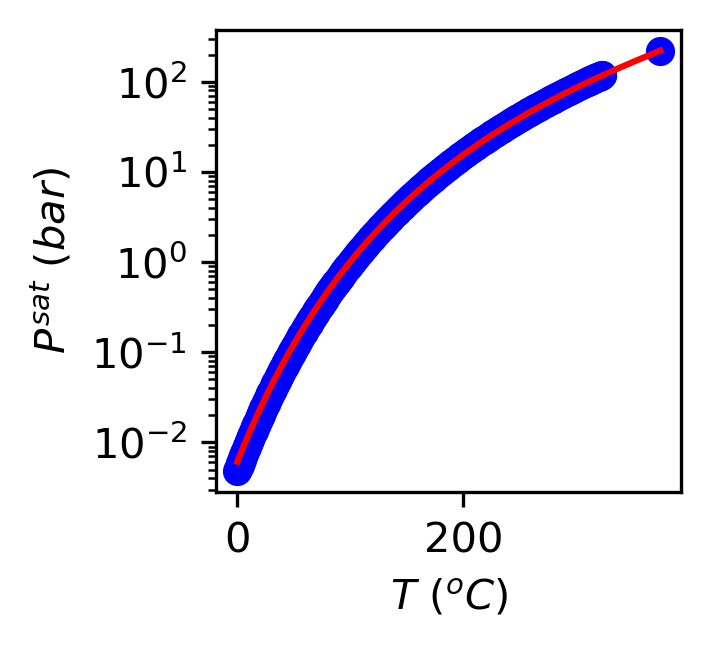

In [125]:
plt.figure(dpi=300, figsize=(2,2))
plt.plot(np.asarray(Tsat)-273.15, Psat, 'ob')
plt.plot(steam_properties['Temperature (K)'] - 273.15, 
         steam_properties['Pressure (MPa)']*10, '-r')

#plt.plot([0, 0, 238.5-273.15], [0.00611657, 1.01325, 2099])
plt.ylabel(r'$P^{sat}$ $(bar)$')
plt.xlabel(r'$T$ $(^o C)$')
plt.yscale('log')
#plt.xscale('log')
plt.show()

### [Phase Diagram for Water](https://en.m.wikipedia.org/wiki/File:Phase_diagram_of_water.svg)

Major talking points on the above image:

1. [Triple Point](https://www.youtube.com/watch?v=Juz9pVVsmQQ) (DOF = 0, C=1, P=3)
2. Solid Phase Equilibrium
    - **[Sublimation](https://www.youtube.com/watch?v=8Gj8dr6AsYg)** - solid to gas transition
    - **Melting** - solid to liquid transition
3. Ice Phases
    - **[Exotic forms of ice](https://www.youtube.com/watch?v=dER6E2cb-y4)** - Experiments on ice structure
    - **[Diamon Anvil](https://www.youtube.com/watch?v=W-FqE81rhqA)**
[Check out this PBS Spacetime Video](https://www.youtube.com/watch?v=eyn7MusdQ9g)



## First Order Phase Transition
Phase transitions can be classified based on the order of the transition, which refers to the nature of the change in the thermodynamic properties of the system. The two main types are **first-order** and **second-order** (or higher-order) phase transitions.

1. **First-Order Phase Transitions**:
   - **Definition**: These transitions involve a discontinuous change in some thermodynamic quantity, such as density or entropy. They are characterized by the absorption or release of latent heat.
   - **Examples**: Melting of ice, boiling of water, and condensation of steam.
   - **Characteristics**:
     - Discontinuous change in properties (e.g., volume, entropy).
     - Latent heat is involved.
     - Coexistence of phases at the transition temperature and pressure.

2. **Second-Order (or Continuous) Phase Transitions**:
   - **Definition**: These transitions involve a continuous change in the thermodynamic properties of the system. There is no latent heat involved.
   - **Examples**: The transition from a ferromagnetic to a paramagnetic state at the Curie point.
   - **Characteristics**:
     - Continuous change in properties.
     - No latent heat.
     - Divergence in specific heat, susceptibility, or other response functions.

For more detailed information, you can refer to resources like the [Wikipedia page on Phase Transitions](https://en.wikipedia.org/wiki/Phase_transition)

### Order of a phase transition:
*First-order phase transitions exhibit a discontinuity in the first derivative of the free energy with respect to some thermodynamic variable.*

Lets plot the Gibb's Free Energy as a function of Pressure and Temperature for several isotherms:


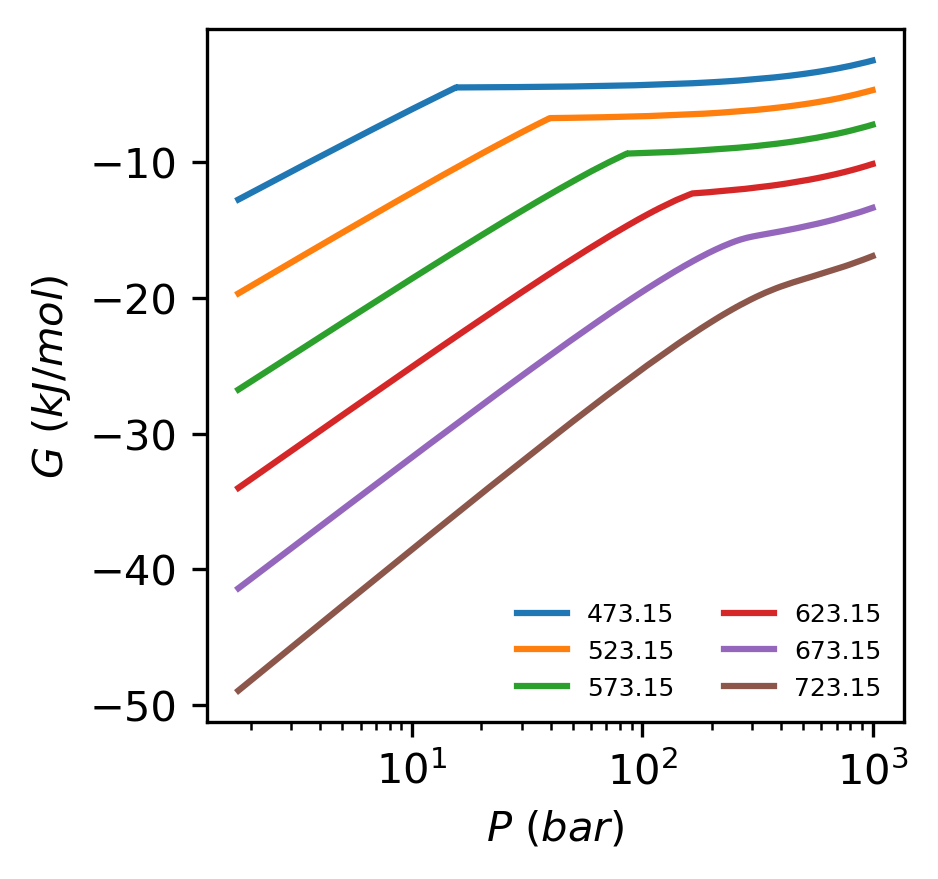

In [108]:
directory = 'data'

plt.figure(dpi=300,figsize=(3,3))
for filename in os.listdir(directory):    
    if('isotherm' in filename):
        isotherm = pd.read_csv(os.path.join(directory, filename), delimiter = '\t')

        H = isotherm['Enthalpy (kJ/mol)']
        S = isotherm['Entropy (J/mol*K)']
        T = isotherm['Temperature (K)']
        P = isotherm['Pressure (MPa)']*10
        G = H*1000 - T*S

        plt.plot(P[1:], G[1:]/1000, label = filename.split('_')[1].strip('T=').strip('K.txt'))

plt.ylabel(r'$G$ $(kJ/mol)$')
plt.xlabel(r'$P$ $(bar)$')
#plt.yscale('log')
plt.xscale('log')
plt.legend(ncols =2, frameon = False, fontsize=6)
plt.show()


The implication of the statement above is that:

$$\bigg(\dfrac{\partial \underline{G}}{\partial P}\bigg)_T$$

will exhibit one discontinuity at the onset of the vapor to fluid transition such that:

$$
\bigg(\dfrac{\partial \underline{G}}{\partial P}\bigg)_T^v \ne 
\bigg(\dfrac{\partial \underline{G}}{\partial P}\bigg)_T^l
$$\

We can see if this is the case for the conditions above by taking the first derivative of the $\underline{G}(P, T)$ function at constant temperature. bigg(\dfrac{\partial \underline{G}}{\partial P}\bigg)_T$$$$\bigg(\dfrac{\partial \underline{G}}{\partial P}\bigg)_T$$$$


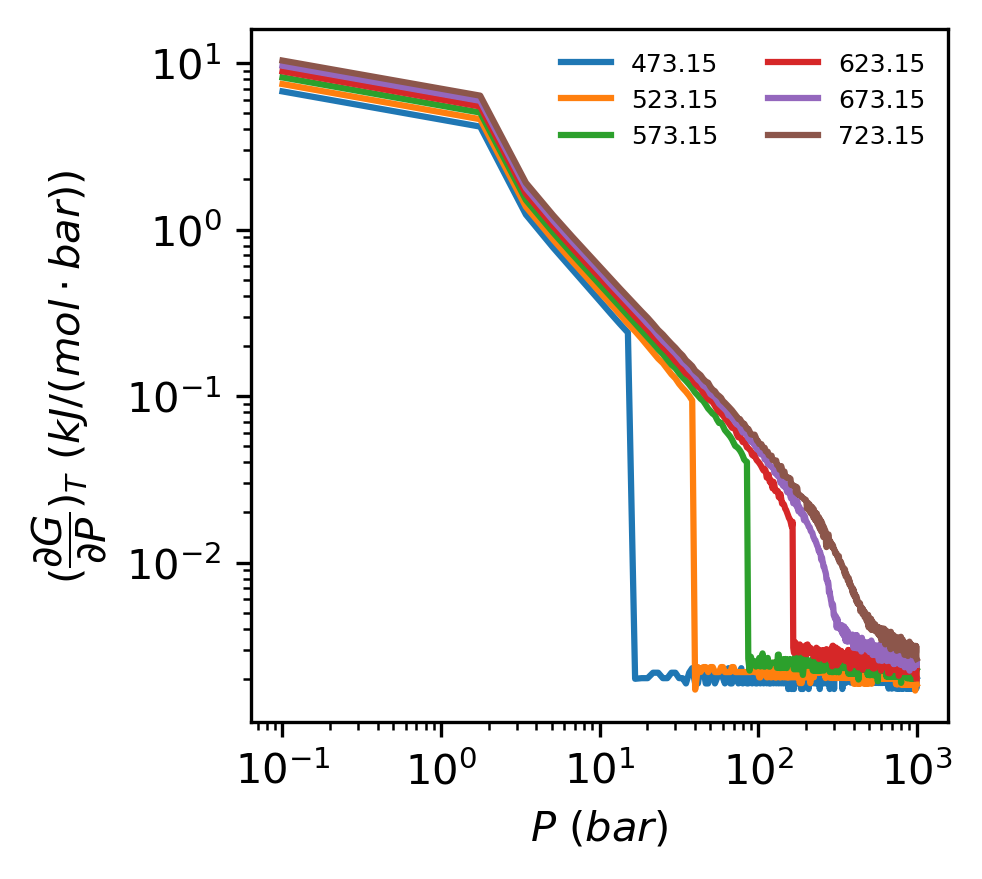

In [124]:
directory = 'data'
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

plt.figure(dpi=300,figsize=(3,3))
for filename in os.listdir(directory):    
    if('isotherm' in filename):
        isotherm = pd.read_csv(os.path.join(directory, filename), delimiter = '\t')

        H = isotherm['Enthalpy (kJ/mol)']
        S = isotherm['Entropy (J/mol*K)']
        T = isotherm['Temperature (K)']
        P = isotherm['Pressure (MPa)']*10
        G = H*1000 - T*S
        dGdP = np.gradient(G/1000, P);
        mask = (dGdP > 0)
        plt.plot(P[mask], dGdP[mask], label = filename.split('_')[1].strip('T=').strip('K.txt'))

plt.ylabel(r'$(\dfrac{\partial G}{\partial P})_T$ $(kJ/(mol\cdot bar))$')
plt.xlabel(r'$P$ $(bar)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(ncols =2, frameon = False, fontsize=6)
plt.show()


## Clausius-Clapyron Equation
Sure! The Clausius-Clapeyron equation describes the relationship between the vapor pressure and temperature of a substance during a phase transition. Here's a step-by-step derivation:

1. **Start with the Gibbs Free Energy**:
   For two phases in equilibrium (e.g., liquid and vapor), the Gibbs free energy per mole $\underline{G}$ is equal:
   $$
   \underline{G}^{l} = \underline{G}^{v}
   $$

2. **Differential Form of Gibbs Free Energy**:
   The differential form of the Gibbs free energy is:
   $$
   d\underline{G} = \underline{V}dP - \underline{S}dT
   $$
   where $\underline{V}$ is the molar volume, $P$ is the pressure, $\underline{S}$ is the entropy, and $T$ is the temperature.

3. **Equilibrium Condition**:
   At equilibrium, the change in Gibbs free energy for both phases must be equal:
   $$
   d\underline{G}^{l} = d\underline{G}^{v}
   $$
   Therefore:
   $$
   \underline{V}^l dP - \underline{S}^l dT = \underline{V}^v dP - \underline{S}^v dT
   $$

4. **Rearrange the Equation**:
   Rearrange to isolate $dP/dT$:
   $$
   (\underline{V}^v - \underline{V}^l) dP = (\underline{S}^v - \underline{S}^l) dT
   $$
   $$
   \frac{dP}{dT} = \frac{\underline{S}^v - \underline{S}^l}{\underline{V}^v - \underline{V}^l}
   $$

5. **Entropy Change**:
   The entropy change $\Delta \underline{S}$ during the phase transition is related to the enthalpy change $\Delta \underline{H}$ by:
   $$
   \Delta \underline{S} = \frac{\Delta \underline{H}}{T}
   $$

> Note that we get this from the relationship that $d\underline{H} = \underline{V}dP - Td\underline{S}$. When a phase change occurs, the $dP=0$ from the vapor to the liquid phase. 

6. **Substitute Entropy Change**:
   Substitute $\Delta \underline{S}$ into the equation:
   $$
   \frac{dP}{dT} = \frac{\Delta \underline{H}}{T (\underline{V}^v - \underline{V}^l)}
   $$

7. **Ideal Gas Approximation**:
   For the vapor phase, we can use the ideal gas law $V^v = \frac{RT}{P}$, and since $\underline{V}^v>>\underline{V}^l$, we approximate $\underline{V}^v - \underline{V}^l \sim \underline{V}^v$:
   $$
   \frac{dP}{dT} = \frac{\Delta \underline{H}}{T \left(\frac{RT}{P}\right)}
   $$
   This simplifies to:
   $$
   \frac{dP}{dT} = \frac{P \Delta \underline{H}}{R T^2}
   $$

8. **Integrate the Equation**:
   Integrate both sides to obtain the Clausius-Clapeyron equation:
   $$
   \int_{P_1}^{P_2} \frac{dP}{P} = \frac{\Delta \underline{H}}{R} \int_{T_1}^{T_2} \frac{dT}{T^2}
   $$
   $$
   \ln \left(\frac{P_2}{P_1}\right) = -\frac{\Delta_{vap} \underline{H}}{R} \left(\frac{1}{T_2} - \frac{1}{T_1}\right)
   $$

This is the Clausius-Clapeyron equation, which relates the change in vapor pressure to the change in temperature for a phase transition.

The equation states that if I know the latent heat of vaporization, $\Delta \underline{H}^{v\rightarrow l}$ at a given temperature $T_1$ and pressure $P_1$, then I can predict the equilibrium vapor pressure, $P_2$, of a substance at difference temperature $T_2$.

### Test your understanding:

Work illustration problem 7.7-1 in Sandler and 7.18a in the back of the book.


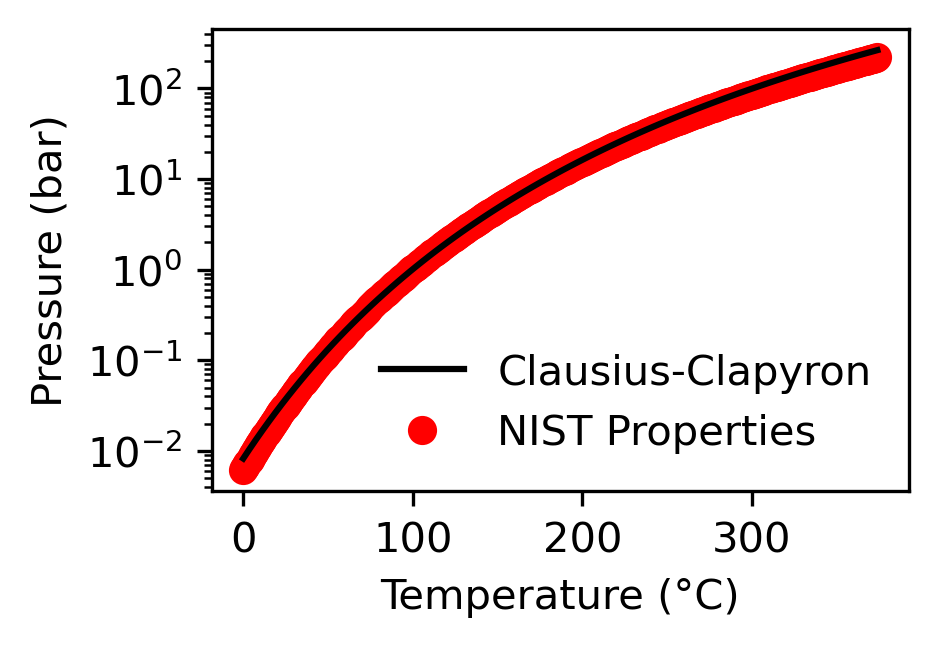

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

directory = 'data'
filename = 'saturated_steam_properties.txt'

steam_properties = pd.read_csv(os.path.join(directory, filename), delimiter = '\t')
# Constants
R = 8.314  # Universal gas constant, J/(mol*K)
delta_H_vap = 40.79e3  # Enthalpy of vaporization for water, J/mol

# Function to calculate vapor pressure using Clausius-Clapeyron equation
def vapor_pressure(T1, P1, T2):
    return P1 * np.exp(-delta_H_vap / R * (1/T2 - 1/T1))

# Given data
T1 = 373.15  # Boiling point of water at 1 atm in Kelvin (100°C)
P1 = 101325  # Vapor pressure at boiling point in Pa (1 atm)

# Temperature range for the plot
T = np.linspace(273.15, np.max(steam_properties['Temperature (K)']), 100)  # From 0°C to 100°C in Kelvin

# Calculate vapor pressures for the temperature range
P = vapor_pressure(T1, P1, T)

# Plot the results
plt.figure(figsize=(3, 2), dpi=300)
plt.plot(T - 273.15, P / 10**5, '-k', label = 'Clausius-Clapyron')  # Convert temperature to °C and pressure to kPa
plt.plot(steam_properties['Temperature (K)'] - 273.15,
         steam_properties['Pressure (MPa)']*10, 
         'or', zorder = 1, label = 'NIST Properties')
#plt.plot(steam_properties
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (bar)')
plt.yscale('log')
#plt.xscale('log')
plt.legend(frameon=False)
plt.show()


## Antoine Equation

The transition from step 7 above to 8 required a definite integral. If instead, an indefinite integration of the equation:

$$
\frac{dP}{dT} = \frac{P \Delta \underline{H}}{R T^2}
$$

and by rearrangement:
$$
\frac{1}{P}dP = \frac{B}{T^2}dT
$$

where $B=\Delta \underline{H}/R$

Integration of the above yields:

$$
lnP^{vap} = -\frac{B}{T} + A
$$

In practice, an emperical relationship is used, called the **Antoine Equation**

$$
\log{P^{vap}} = A - \dfrac{B}{T + C}
$$
### As the Antoine Equation is Empirical, the parameters A, B, and C need to be determined through a curve fit:

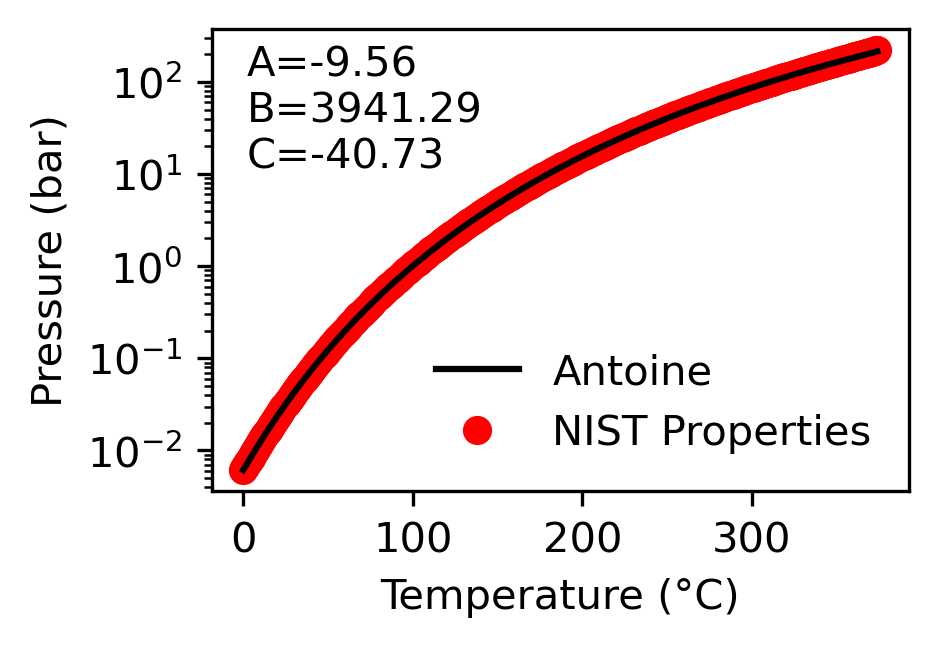

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import curve_fit
directory = 'data'
filename = 'saturated_steam_properties.txt'

steam_properties = pd.read_csv(os.path.join(directory, filename), delimiter = '\t')
# Constants
R = 8.314  # Universal gas constant, J/(mol*K)
delta_H_vap = 40.79e3  # Enthalpy of vaporization for water, J/mol

# Function to calculate vapor pressure using Clausius-Clapeyron equation
def log_vapor_pressure(T, A, B, C):
    
    return -A-B/(T+C)

T = steam_properties['Temperature (K)']
P = steam_properties['Pressure (MPa)']
lnP = np.log(steam_properties['Pressure (MPa)'])

popt, cov = curve_fit(log_vapor_pressure, T, lnP)

# Plot the results
plt.figure(figsize=(3, 2), dpi=300)
plt.plot(T - 273.15, np.exp(log_vapor_pressure(T, *popt))*10, '-k', label = 'Antoine')  # Convert temperature to °C and pressure to kPa
plt.plot(steam_properties['Temperature (K)'] - 273.15,
         steam_properties['Pressure (MPa)']*10, 
         'or', zorder = 1, label = 'NIST Properties')
#plt.plot(steam_properties
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (bar)')
plt.yscale('log')
#plt.xscale('log')
plt.legend(frameon=False)

plt.annotate('A=%3.2f'%popt[0], xy=(0.05, 0.90), xycoords = 'axes fraction')
plt.annotate('B=%3.2f'%popt[1], xy=(0.05, 0.80), xycoords = 'axes fraction')
plt.annotate('C=%3.2f K'%popt[2], xy=(0.05, 0.70), xycoords = 'axes fraction')

plt.show()
